In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

In [2]:
df = pd.read_excel('/Users/apple/Workspace/customer_segmentation/online_retail_II.xlsx', sheet_name=0)
df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


# Exploratory Data Analysis

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 525461 entries, 0 to 525460
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   Invoice      525461 non-null  object        
 1   StockCode    525461 non-null  object        
 2   Description  522533 non-null  object        
 3   Quantity     525461 non-null  int64         
 4   InvoiceDate  525461 non-null  datetime64[ns]
 5   Price        525461 non-null  float64       
 6   Customer ID  417534 non-null  float64       
 7   Country      525461 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 32.1+ MB


In [4]:
df.describe()

,Quantity,InvoiceDate,Price,Customer ID
count,525461.000000,525461,525461.000000,417534.000000
mean,10.337667,2010-06-28 11:37:36.845017856,4.688834,15360.645478
min,-9600.000000,2009-12-01 07:45:00,-53594.360000,12346.000000
25%,1.000000,2010-03-21 12:20:00,1.250000,13983.000000
50%,3.000000,2010-07-06 09:51:00,2.100000,15311.000000
75%,10.000000,2010-10-15 12:45:00,4.210000,16799.000000
max,19152.000000,2010-12-09 20:01:00,25111.090000,18287.000000
std,107.424110,NaN,146.126914,1680.811316


In [5]:
df.describe(include= "O")

,Invoice,StockCode,Description,Country
count,525461,525461,522533,525461
unique,28816,4632,4681,40
top,537434,85123A,WHITE HANGING HEART T-LIGHT HOLDER,United Kingdom
freq,675,3516,3549,485852


In [6]:
df[df['Customer ID'].isnull()].head(10)

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
263,489464,21733,85123a mixed,-96,2009-12-01 10:52:00,0.00,NaN,United Kingdom
283,489463,71477,short,-240,2009-12-01 10:52:00,0.00,NaN,United Kingdom
284,489467,85123A,21733 mixed,-192,2009-12-01 10:53:00,0.00,NaN,United Kingdom
470,489521,21646,NaN,-50,2009-12-01 11:44:00,0.00,NaN,United Kingdom
577,489525,85226C,BLUE PULL BACK RACING CAR,1,2009-12-01 11:49:00,0.55,NaN,United Kingdom
578,489525,85227,SET/6 3D KIT CARDS FOR KIDS,1,2009-12-01 11:49:00,0.85,NaN,United Kingdom
1055,489548,22271,FELTCRAFT DOLL ROSIE,1,2009-12-01 12:32:00,2.95,NaN,United Kingdom
1056,489548,22254,FELT TOADSTOOL LARGE,12,2009-12-01 12:32:00,1.25,NaN,United Kingdom
1057,489548,22273,FELTCRAFT DOLL MOLLY,3,2009-12-01 12:32:00,2.95,NaN,United Kingdom
1058,489548,22195,LARGE HEART MEASURING SPOONS,1,2009-12-01 12:32:00,1.65,NaN,United Kingdom


In [7]:
df[df['Quantity'] < 0].head(10)

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
178,C489449,22087,PAPER BUNTING WHITE LACE,-12,2009-12-01 10:33:00,2.95,16321.0,Australia
179,C489449,85206A,CREAM FELT EASTER EGG BASKET,-6,2009-12-01 10:33:00,1.65,16321.0,Australia
180,C489449,21895,POTTING SHED SOW 'N' GROW SET,-4,2009-12-01 10:33:00,4.25,16321.0,Australia
181,C489449,21896,POTTING SHED TWINE,-6,2009-12-01 10:33:00,2.10,16321.0,Australia
182,C489449,22083,PAPER CHAIN KIT RETRO SPOT,-12,2009-12-01 10:33:00,2.95,16321.0,Australia
183,C489449,21871,SAVE THE PLANET MUG,-12,2009-12-01 10:33:00,1.25,16321.0,Australia
184,C489449,84946,ANTIQUE SILVER TEA GLASS ETCHED,-12,2009-12-01 10:33:00,1.25,16321.0,Australia
185,C489449,84970S,HANGING HEART ZINC T-LIGHT HOLDER,-24,2009-12-01 10:33:00,0.85,16321.0,Australia
186,C489449,22090,PAPER BUNTING RETRO SPOTS,-12,2009-12-01 10:33:00,2.95,16321.0,Australia
196,C489459,90200A,PURPLE SWEETHEART BRACELET,-3,2009-12-01 10:44:00,4.25,17592.0,United Kingdom


In [8]:
df['Invoice'] = df['Invoice'].astype(str)
df[df['Invoice'].str.match('^\\d{6}$')==False]

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
178,C489449,22087,PAPER BUNTING WHITE LACE,-12,2009-12-01 10:33:00,2.95,16321.0,Australia
179,C489449,85206A,CREAM FELT EASTER EGG BASKET,-6,2009-12-01 10:33:00,1.65,16321.0,Australia
180,C489449,21895,POTTING SHED SOW 'N' GROW SET,-4,2009-12-01 10:33:00,4.25,16321.0,Australia
181,C489449,21896,POTTING SHED TWINE,-6,2009-12-01 10:33:00,2.10,16321.0,Australia
182,C489449,22083,PAPER CHAIN KIT RETRO SPOT,-12,2009-12-01 10:33:00,2.95,16321.0,Australia
...,...,...,...,...,...,...,...,...
524695,C538123,22956,36 FOIL HEART CAKE CASES,-2,2010-12-09 15:41:00,2.10,12605.0,Germany
524696,C538124,M,Manual,-4,2010-12-09 15:43:00,0.50,15329.0,United Kingdom
524697,C538124,22699,ROSES REGENCY TEACUP AND SAUCER,-1,2010-12-09 15:43:00,2.95,15329.0,United Kingdom
524698,C538124,22423,REGENCY CAKESTAND 3 TIER,-1,2010-12-09 15:43:00,12.75,15329.0,United Kingdom


In [9]:
df['Invoice'].str.replace('[0-9]', '', regex = True).unique()

array(['', 'C', 'A'], dtype=object)

In [10]:
df[df['Invoice'].str.startswith('A')]

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
179403,A506401,B,Adjust bad debt,1,2010-04-29 13:36:00,-53594.36,NaN,United Kingdom
276274,A516228,B,Adjust bad debt,1,2010-07-19 11:24:00,-44031.79,NaN,United Kingdom
403472,A528059,B,Adjust bad debt,1,2010-10-20 12:04:00,-38925.87,NaN,United Kingdom


In [11]:
df['StockCode'] = df['StockCode'].astype(str)
df[(df['StockCode'].str.match('^\\d{5}$')==False)&(df['StockCode'].str.match('^\\d{5}[a-zA-Z]+$')==False)]['StockCode'].unique()

array(['POST', 'D', 'DCGS0058', 'DCGS0068', 'DOT', 'M', 'DCGS0004',
       'DCGS0076', 'C2', 'BANK CHARGES', 'DCGS0003', 'TEST001',
       'gift_0001_80', 'DCGS0072', 'gift_0001_20', 'DCGS0044', 'TEST002',
       'gift_0001_10', 'gift_0001_50', 'DCGS0066N', 'gift_0001_30',
       'PADS', 'ADJUST', 'gift_0001_40', 'gift_0001_60', 'gift_0001_70',
       'gift_0001_90', 'DCGSSGIRL', 'DCGS0006', 'DCGS0016', 'DCGS0027',
       'DCGS0036', 'DCGS0039', 'DCGS0060', 'DCGS0056', 'DCGS0059', 'GIFT',
       'DCGSLBOY', 'm', 'DCGS0053', 'DCGS0062', 'DCGS0037', 'DCGSSBOY',
       'DCGSLGIRL', 'S', 'DCGS0069', 'DCGS0070', 'DCGS0075', 'B',
       'DCGS0041', 'ADJUST2', '47503J ', 'C3', 'SP1002', 'AMAZONFEE'],
      dtype=object)

In [12]:
df[df['StockCode'].str.contains("DOT")]

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
2379,489597,DOT,DOTCOM POSTAGE,1,2009-12-01 14:28:00,647.19,NaN,United Kingdom
2539,489600,DOT,DOTCOM POSTAGE,1,2009-12-01 14:43:00,55.96,NaN,United Kingdom
2551,489601,DOT,DOTCOM POSTAGE,1,2009-12-01 14:44:00,68.39,NaN,United Kingdom
2571,489602,DOT,DOTCOM POSTAGE,1,2009-12-01 14:45:00,59.35,NaN,United Kingdom
2619,489603,DOT,DOTCOM POSTAGE,1,2009-12-01 14:46:00,42.39,NaN,United Kingdom
...,...,...,...,...,...,...,...,...
524272,538071,DOT,DOTCOM POSTAGE,1,2010-12-09 14:09:00,885.94,NaN,United Kingdom
524887,538148,DOT,DOTCOM POSTAGE,1,2010-12-09 16:26:00,547.32,NaN,United Kingdom
525000,538149,DOT,DOTCOM POSTAGE,1,2010-12-09 16:27:00,620.68,NaN,United Kingdom
525126,538153,DOT,DOTCOM POSTAGE,1,2010-12-09 16:31:00,822.94,NaN,United Kingdom


# Data Cleaning

In [13]:
cleaned_df = df.copy()

In [14]:
cleaned_df['Invoice'] = cleaned_df['Invoice'].astype(str)

match = (cleaned_df['Invoice'].str.match('^\\d{6}$')==True)

cleaned_df = cleaned_df[match]

cleaned_df

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom
...,...,...,...,...,...,...,...,...
525456,538171,22271,FELTCRAFT DOLL ROSIE,2,2010-12-09 20:01:00,2.95,17530.0,United Kingdom
525457,538171,22750,FELTCRAFT PRINCESS LOLA DOLL,1,2010-12-09 20:01:00,3.75,17530.0,United Kingdom
525458,538171,22751,FELTCRAFT PRINCESS OLIVIA DOLL,1,2010-12-09 20:01:00,3.75,17530.0,United Kingdom
525459,538171,20970,PINK FLORAL FELTCRAFT SHOULDER BAG,2,2010-12-09 20:01:00,3.75,17530.0,United Kingdom


In [15]:
cleaned_df['StockCode'] = cleaned_df['StockCode'].astype(str)

mask = (
    (cleaned_df['StockCode'].str.match('^\\d{5}$')==True)

|(cleaned_df['StockCode'].str.match('^\\d{5}[a-zA-Z]+$')==True)

| (cleaned_df['StockCode'].str.match("^PADS$")==True)

)

cleaned_df = cleaned_df[mask]
cleaned_df

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom
...,...,...,...,...,...,...,...,...
525456,538171,22271,FELTCRAFT DOLL ROSIE,2,2010-12-09 20:01:00,2.95,17530.0,United Kingdom
525457,538171,22750,FELTCRAFT PRINCESS LOLA DOLL,1,2010-12-09 20:01:00,3.75,17530.0,United Kingdom
525458,538171,22751,FELTCRAFT PRINCESS OLIVIA DOLL,1,2010-12-09 20:01:00,3.75,17530.0,United Kingdom
525459,538171,20970,PINK FLORAL FELTCRAFT SHOULDER BAG,2,2010-12-09 20:01:00,3.75,17530.0,United Kingdom


In [16]:
cleaned_df.dropna(subset = ['Customer ID'], inplace = True)
cleaned_df

/var/folders/k1/1kj0mp0j4vdfm5spx_2bcdpm0000gn/T/ipykernel_43537/3513097649.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  cleaned_df.dropna(subset = ['Customer ID'], inplace = True)


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom
...,...,...,...,...,...,...,...,...
525456,538171,22271,FELTCRAFT DOLL ROSIE,2,2010-12-09 20:01:00,2.95,17530.0,United Kingdom
525457,538171,22750,FELTCRAFT PRINCESS LOLA DOLL,1,2010-12-09 20:01:00,3.75,17530.0,United Kingdom
525458,538171,22751,FELTCRAFT PRINCESS OLIVIA DOLL,1,2010-12-09 20:01:00,3.75,17530.0,United Kingdom
525459,538171,20970,PINK FLORAL FELTCRAFT SHOULDER BAG,2,2010-12-09 20:01:00,3.75,17530.0,United Kingdom


In [17]:
cleaned_df.describe()

,Quantity,InvoiceDate,Price,Customer ID
count,406337.000000,406337,406337.000000,406337.000000
mean,13.619099,2010-07-01 10:11:06.543288320,2.991462,15373.632992
min,1.000000,2009-12-01 07:45:00,0.000000,12346.000000
25%,2.000000,2010-03-26 14:01:00,1.250000,14004.000000
50%,5.000000,2010-07-09 15:48:00,1.950000,15326.000000
75%,12.000000,2010-10-14 17:09:00,3.750000,16814.000000
max,19152.000000,2010-12-09 20:01:00,295.000000,18287.000000
std,97.000659,NaN,4.285876,1677.365907


In [18]:
len(cleaned_df[cleaned_df['Price']==0])

28

In [19]:
cleaned_df = cleaned_df[cleaned_df['Price']>0]

In [20]:
cleaned_df.describe()

,Quantity,InvoiceDate,Price,Customer ID
count,406309.000000,406309,406309.000000,406309.000000
mean,13.617924,2010-07-01 10:14:25.869572352,2.991668,15373.722268
min,1.000000,2009-12-01 07:45:00,0.001000,12346.000000
25%,2.000000,2010-03-26 14:01:00,1.250000,14006.000000
50%,5.000000,2010-07-09 15:48:00,1.950000,15326.000000
75%,12.000000,2010-10-14 17:09:00,3.750000,16814.000000
max,19152.000000,2010-12-09 20:01:00,295.000000,18287.000000
std,96.998833,NaN,4.285951,1677.329470


In [21]:
data_loss = (df.shape[0] - cleaned_df.shape[0]) / df.shape[0] * 100
print(f"Data loss after cleaning: {data_loss:.2f}%")

Data loss after cleaning: 22.68%


# Feature Engineering

In [22]:
cleaned_df["SalesTotal"] = cleaned_df["Quantity"] * cleaned_df["Price"]
cleaned_df.head()

/var/folders/k1/1kj0mp0j4vdfm5spx_2bcdpm0000gn/T/ipykernel_43537/3693171788.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  cleaned_df["SalesTotal"] = cleaned_df["Quantity"] * cleaned_df["Price"]


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,SalesTotal
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,83.4
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,100.8
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,30.0


In [26]:
aggregated_df = cleaned_df.groupby(by= "Customer ID",as_index=False).agg(
    MonetaryValue = ("SalesTotal", "sum"),
    Frequency = ("Invoice", "nunique"),
    LastPurchase = ("InvoiceDate", "max"))
aggregated_df.head()

,Customer ID,MonetaryValue,Frequency,LastPurchase
0,12346.0,169.36,2,2010-06-28 13:53:00
1,12347.0,1323.32,2,2010-12-07 14:57:00
2,12348.0,221.16,1,2010-09-27 14:59:00
3,12349.0,2221.14,2,2010-10-28 08:23:00
4,12351.0,300.93,1,2010-11-29 15:23:00


In [29]:
max_date = aggregated_df['LastPurchase'].max()

aggregated_df['Recency'] = (max_date - aggregated_df['LastPurchase']).dt.days

aggregated_df.head()

,Customer ID,MonetaryValue,Frequency,LastPurchase,Recency
0,12346.0,169.36,2,2010-06-28 13:53:00,164
1,12347.0,1323.32,2,2010-12-07 14:57:00,2
2,12348.0,221.16,1,2010-09-27 14:59:00,73
3,12349.0,2221.14,2,2010-10-28 08:23:00,42
4,12351.0,300.93,1,2010-11-29 15:23:00,10


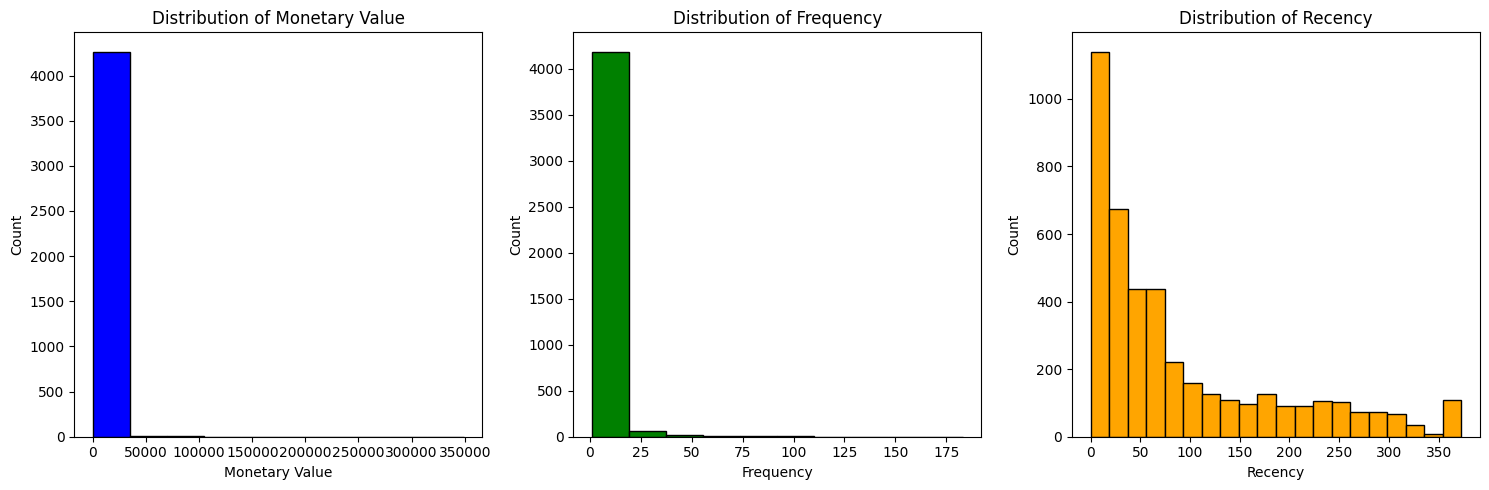

In [32]:
plt.figure(figsize=(15,5))

plt.subplot(1,3,1)
plt.hist(aggregated_df['MonetaryValue'], bins=10, color='blue', edgecolor='black')
plt.title('Distribution of Monetary Value')
plt.xlabel('Monetary Value')
plt.ylabel('Count')

plt.subplot(1,3,2)
plt.hist(aggregated_df['Frequency'], bins=10, color='green', edgecolor='black')
plt.title('Distribution of Frequency')
plt.xlabel('Frequency')
plt.ylabel('Count') 

plt.subplot(1,3,3)
plt.hist(aggregated_df['Recency'], bins=20, color='orange', edgecolor='black')
plt.title('Distribution of Recency')
plt.xlabel('Recency')
plt.ylabel('Count')

plt.tight_layout()
plt.show()

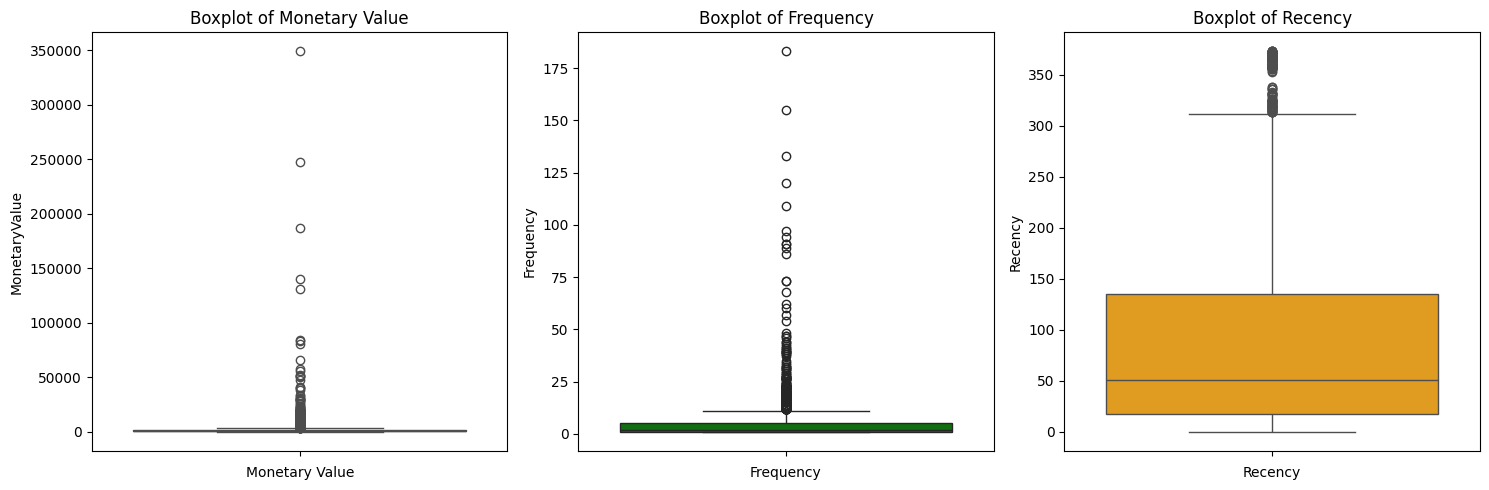

In [34]:
plt.figure(figsize=(15, 5))

plt.subplot(1,3,1)
sns.boxplot(data=aggregated_df['MonetaryValue'], color='blue')
plt.title('Boxplot of Monetary Value')
plt.xlabel('Monetary Value')

plt.subplot(1,3,2)
sns.boxplot(data=aggregated_df['Frequency'], color='green')
plt.title('Boxplot of Frequency')
plt.xlabel('Frequency')

plt.subplot(1,3,3)
sns.boxplot(data=aggregated_df['Recency'], color='orange')
plt.title('Boxplot of Recency')
plt.xlabel('Recency')

plt.tight_layout()
plt.show()

In [36]:
M_Q1 = aggregated_df['MonetaryValue'].quantile(0.25)
M_Q3 = aggregated_df['MonetaryValue'].quantile(0.75)
M_IQR = M_Q3 - M_Q1

monetary_outliers = aggregated_df[(aggregated_df['MonetaryValue'] < M_Q1 - 1.5 * M_IQR) | (aggregated_df['MonetaryValue'] > M_Q3 + 1.5 * M_IQR)].copy()
monetary_outliers.describe()

,Customer ID,MonetaryValue,Frequency,LastPurchase,Recency
count,423.000000,423.000000,423.000000,423,423.000000
mean,15103.040189,12188.101740,17.167849,2010-11-09 12:26:02.978723328,30.035461
min,12357.000000,3802.040000,1.000000,2009-12-10 18:03:00,0.000000
25%,13622.000000,4605.940000,8.000000,2010-11-08 13:17:30,3.000000
50%,14961.000000,6191.320000,12.000000,2010-11-26 12:19:00,13.000000
75%,16692.000000,10273.235000,18.000000,2010-12-06 10:34:30,31.000000
max,18260.000000,349164.350000,183.000000,2010-12-09 19:32:00,364.000000
std,1728.661406,25830.851045,19.729755,NaN,51.541004


In [39]:
M_Q1 = aggregated_df['Frequency'].quantile(0.25)
M_Q3 = aggregated_df['Frequency'].quantile(0.75)
M_IQR = M_Q3 - M_Q1

frequency_outliers = aggregated_df[(aggregated_df['Frequency'] < M_Q1 - 1.5 * M_IQR) | (aggregated_df['Frequency'] > M_Q3 + 1.5 * M_IQR)].copy()
frequency_outliers.describe()

,Customer ID,MonetaryValue,Frequency,LastPurchase,Recency
count,279.000000,279.000000,279.000000,279,279.000000
mean,15352.655914,14409.714932,23.810036,2010-11-23 11:06:20.645161216,16.089606
min,12437.000000,1094.390000,12.000000,2010-05-12 16:51:00,0.000000
25%,13800.000000,4331.560500,13.000000,2010-11-20 13:14:30,2.000000
50%,15465.000000,6615.770000,17.000000,2010-12-02 10:46:00,7.000000
75%,16828.500000,11692.405000,23.000000,2010-12-07 11:08:30,19.000000
max,18260.000000,349164.350000,183.000000,2010-12-09 19:32:00,211.000000
std,1748.429987,31381.736785,21.932937,NaN,26.589117


In [40]:
non_outliers_df = aggregated_df[(~aggregated_df.index.isin(monetary_outliers.index))
                                 & (~aggregated_df.index.isin(frequency_outliers.index))]
non_outliers_df.describe()

,Customer ID,MonetaryValue,Frequency,LastPurchase,Recency
count,3809.000000,3809.000000,3809.000000,3809,3809.000000
mean,15376.482804,885.502197,2.863481,2010-09-03 11:16:46.516146176,97.082174
min,12346.000000,1.550000,1.000000,2009-12-01 10:49:00,0.000000
25%,13912.000000,279.910000,1.000000,2010-07-08 14:48:00,22.000000
50%,15389.000000,588.050000,2.000000,2010-10-12 16:25:00,58.000000
75%,16854.000000,1269.050000,4.000000,2010-11-17 13:14:00,154.000000
max,18287.000000,3788.210000,11.000000,2010-12-09 20:01:00,373.000000
std,1693.199806,817.672283,2.243748,NaN,98.111495


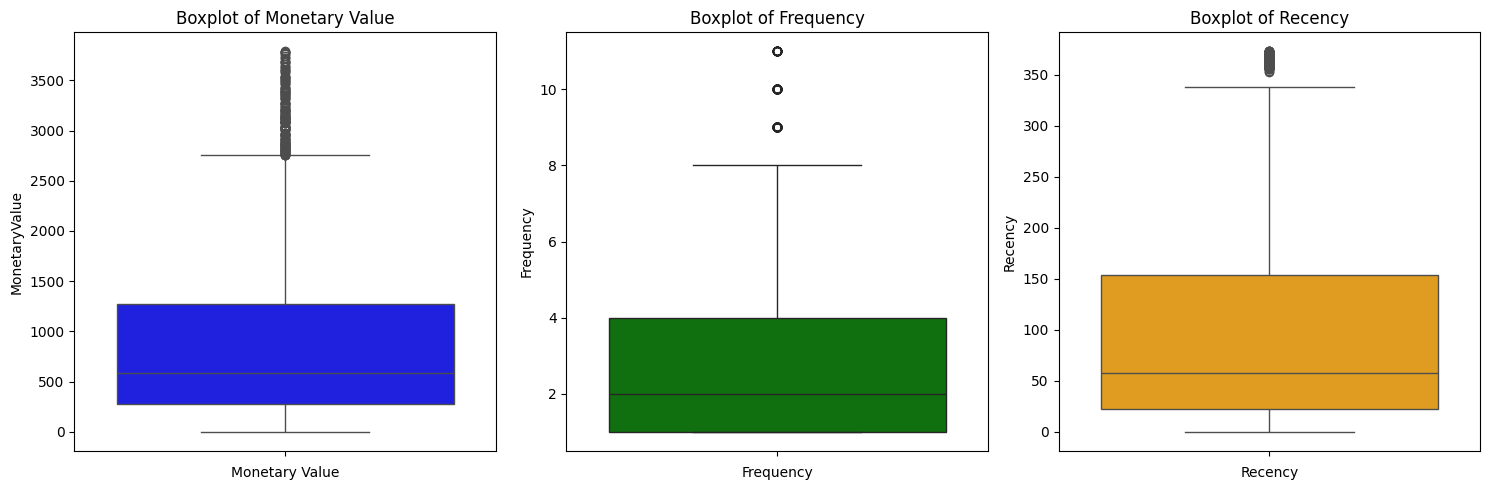

In [42]:
plt.figure(figsize=(15, 5))

plt.subplot(1,3,1)
sns.boxplot(data= non_outliers_df['MonetaryValue'], color='blue')
plt.title('Boxplot of Monetary Value')
plt.xlabel('Monetary Value')    

plt.subplot(1,3,2)
sns.boxplot(data= non_outliers_df['Frequency'], color = 'green')
plt.title('Boxplot of Frequency')
plt.xlabel('Frequency')


plt.subplot(1,3,3)
sns.boxplot(data= non_outliers_df['Recency'],color = 'orange')
plt.title('Boxplot of Recency')
plt.xlabel('Recency')

plt.tight_layout()
plt.show()

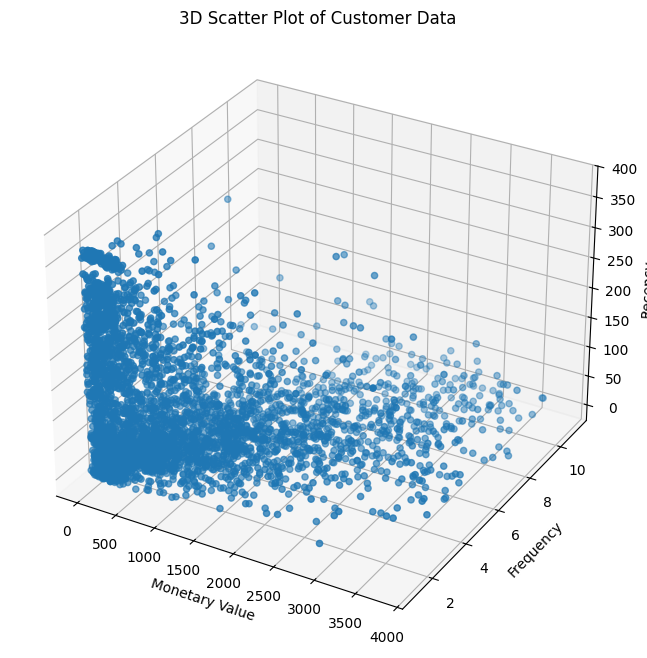

In [45]:
fig = plt.figure(figsize = (8,8))

ax = fig.add_subplot( projection='3d')

ax.scatter(non_outliers_df['MonetaryValue'], non_outliers_df['Frequency'], non_outliers_df['Recency'])

ax.set_xlabel('Monetary Value')
ax.set_ylabel('Frequency')
ax.set_zlabel('Recency')
ax.set_title('3D Scatter Plot of Customer Data')
plt.show()

In [49]:
scaler = StandardScaler()
scaled_data = scaler.fit_transform(non_outliers_df[['MonetaryValue', 'Frequency', 'Recency']])
scaled_data

array([[-0.87594534, -0.38488934,  0.68214853],
       [ 0.5355144 , -0.38488934, -0.96925093],
       [-0.81258645, -0.83063076, -0.24548944],
       ...,
       [-0.62197163, -0.83063076,  2.01753946],
       [ 0.44146683, -0.38488934,  0.14187587],
       [ 1.72488781,  0.50659348, -0.81634357]], shape=(3809, 3))

In [53]:
scaled_df = pd.DataFrame(scaled_data, index = non_outliers_df.index, columns=['MonetaryValue', 'Frequency', 'Recency'])
scaled_df.head()

,MonetaryValue,Frequency,Recency
0,-0.875945,-0.384889,0.682149
1,0.535514,-0.384889,-0.969251
2,-0.812586,-0.830631,-0.245489
3,1.633678,-0.384889,-0.561498
4,-0.715016,-0.830631,-0.887700


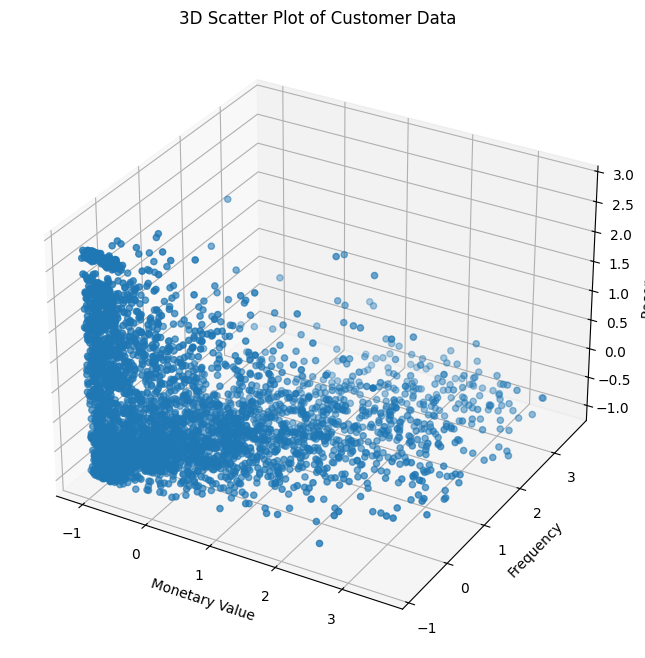

In [55]:
fig = plt.figure(figsize=(8,8))

ax = fig.add_subplot(projection='3d')
scatter = ax.scatter(scaled_df['MonetaryValue'], scaled_df['Frequency'], scaled_df['Recency'])
ax.set_xlabel('Monetary Value')
ax.set_ylabel('Frequency')
ax.set_zlabel('Recency')
ax.set_title('3D Scatter Plot of Customer Data')
plt.show()

## K-Means Clustering

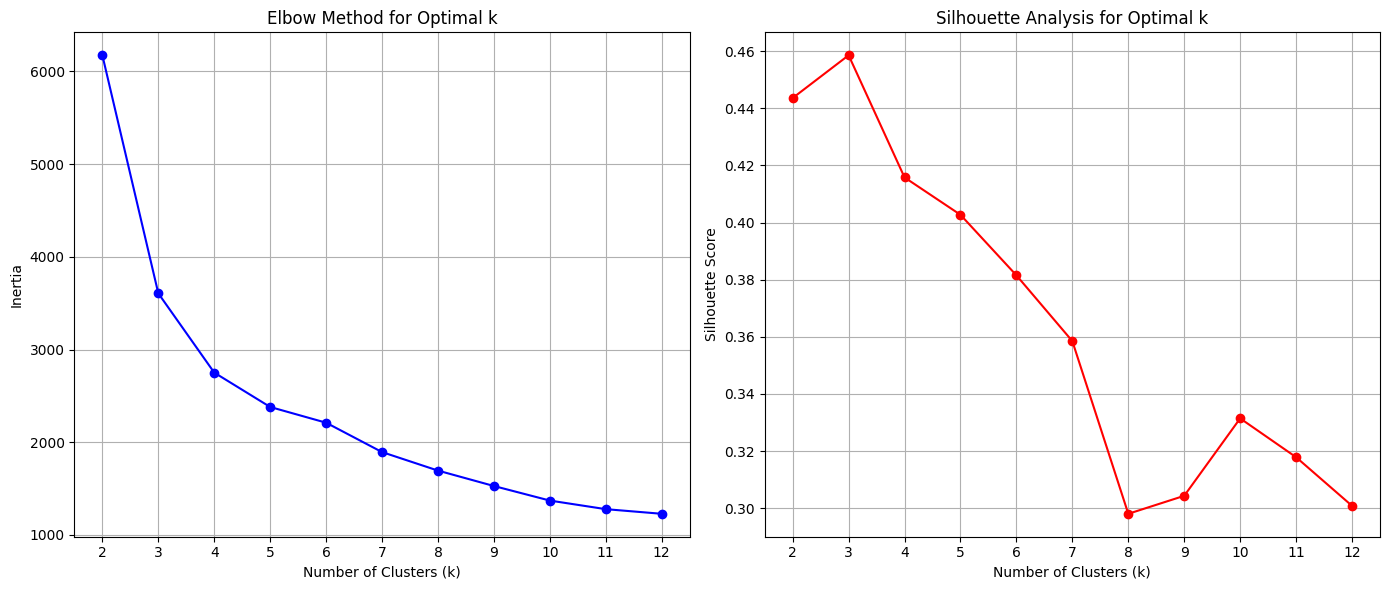

In [60]:
max_k = 12

inertia = []
silhouette_scores = []
k_values = range(2,max_k + 1)

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42, max_iter = 1000)
    cluster_labels = kmeans.fit_predict(scaled_df)
    sill_score = silhouette_score(scaled_df, cluster_labels)
    silhouette_scores.append(sill_score)
    inertia.append(kmeans.inertia_)


plt.figure(figsize = (14,6))

plt.subplot(1,2,1)
plt.plot(k_values, inertia, 'bo-')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method for Optimal k')
plt.xticks(k_values)
plt.grid(True)


plt.subplot(1,2,2)
plt.plot(k_values, silhouette_scores, 'ro-')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Analysis for Optimal k')
plt.xticks(k_values)
plt.grid(True)


plt.tight_layout()
plt.show()

In [61]:
kmeans = KMeans(n_clusters = 4, random_state = 42, max_iter = 1000)

cluster_labels = kmeans.fit_predict(scaled_df)

cluster_labels

array([1, 0, 2, ..., 1, 0, 0], shape=(3809,), dtype=int32)

In [85]:
non_outliers_df['Cluster'] = cluster_labels
non_outliers_df

/var/folders/k1/1kj0mp0j4vdfm5spx_2bcdpm0000gn/T/ipykernel_43537/395619450.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  non_outliers_df['Cluster'] = cluster_labels


,Customer ID,MonetaryValue,Frequency,LastPurchase,Recency,Cluster
0,12346.0,169.36,2,2010-06-28 13:53:00,164,1
1,12347.0,1323.32,2,2010-12-07 14:57:00,2,0
2,12348.0,221.16,1,2010-09-27 14:59:00,73,2
3,12349.0,2221.14,2,2010-10-28 08:23:00,42,0
4,12351.0,300.93,1,2010-11-29 15:23:00,10,2
...,...,...,...,...,...,...
4280,18283.0,641.77,6,2010-11-22 15:30:00,17,0
4281,18284.0,411.68,1,2010-10-04 11:33:00,66,2
4282,18285.0,377.00,1,2010-02-17 10:24:00,295,1
4283,18286.0,1246.43,2,2010-08-20 11:57:00,111,0


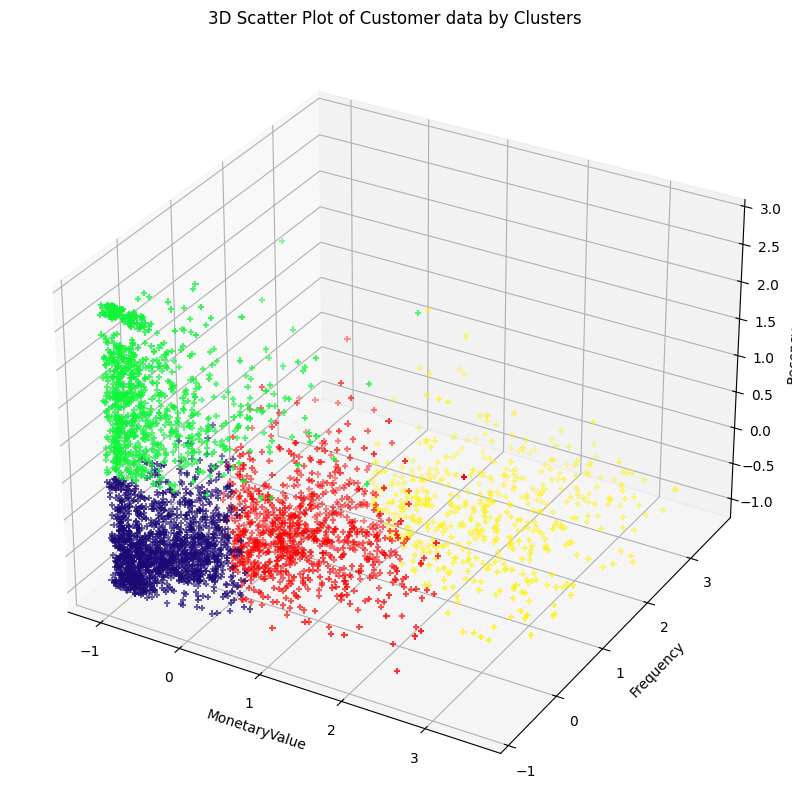

In [75]:
cluster_colors = {0: "#FA0000",
                  1: "#10F43A",
                  2: "#1D0976",
                  3: "#FFF203"
}

colors = non_outliers_df['Cluster'].map(cluster_colors)

fig = plt.figure(figsize= (10,10))

ax = fig.add_subplot(projection = '3d')

scatter = ax.scatter(scaled_df['MonetaryValue'], scaled_df['Frequency'], scaled_df['Recency'], c = colors, marker = '+')

ax.set_xlabel('MonetaryValue')
ax.set_ylabel('Frequency')
ax.set_zlabel('Recency')
ax.set_title('3D Scatter Plot of Customer data by Clusters')
plt.show()

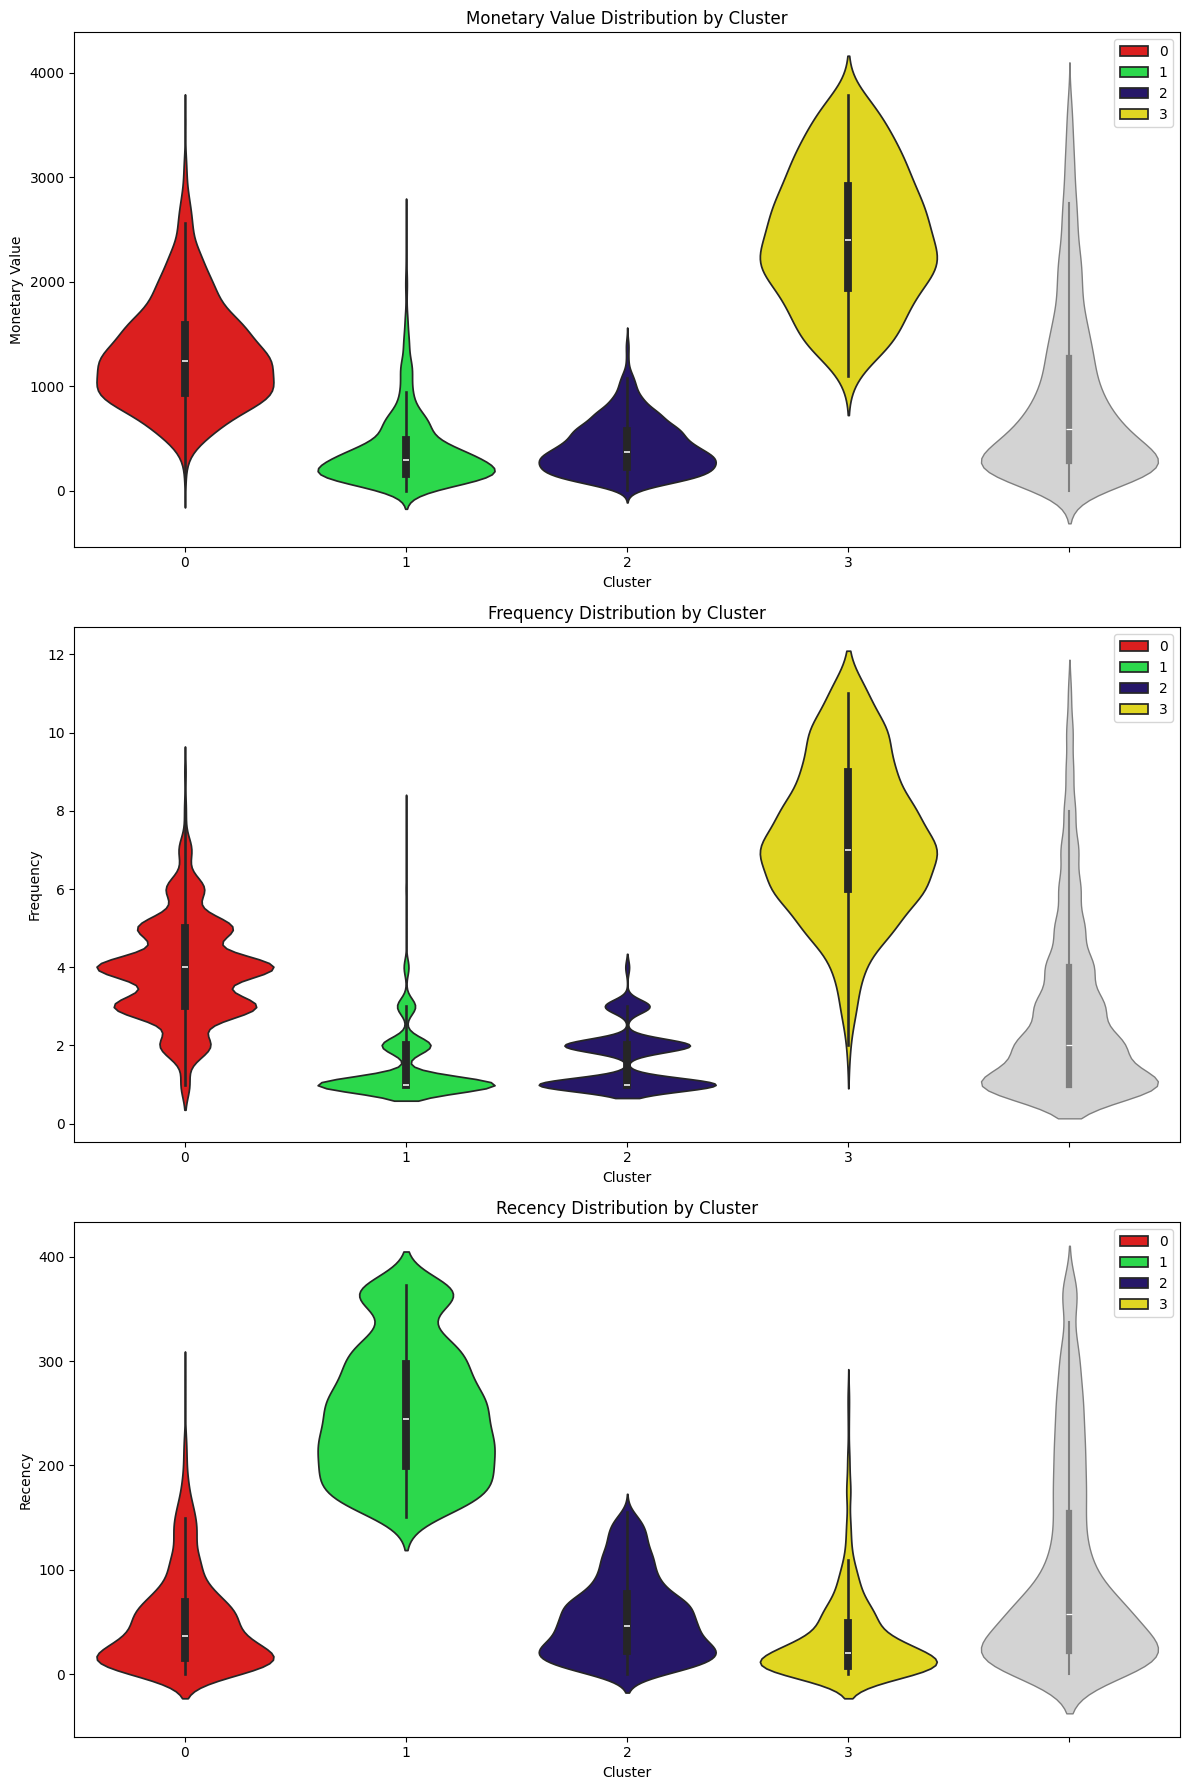

In [76]:
plt.figure(figsize = (12,18))

plt.subplot(3,1,1)
sns.violinplot(x = non_outliers_df['Cluster'], y = non_outliers_df['MonetaryValue'], 
               palette = cluster_colors, hue = non_outliers_df['Cluster'])
sns.violinplot(y = non_outliers_df['MonetaryValue'], color = 'lightgray', linewidth= 1.0)
plt.title('Monetary Value Distribution by Cluster')
plt.ylabel('Monetary Value')

plt.subplot(3,1,2)
sns.violinplot(x = non_outliers_df['Cluster'], y = non_outliers_df['Frequency'], 
               palette = cluster_colors, hue = non_outliers_df['Cluster'])
sns.violinplot(y = non_outliers_df['Frequency'], color = 'lightgray', linewidth= 1.0)
plt.title('Frequency Distribution by Cluster')
plt.ylabel('Frequency')

plt.subplot(3,1,3)
sns.violinplot(x = non_outliers_df['Cluster'], y = non_outliers_df['Recency'], 
               palette= cluster_colors, hue = non_outliers_df['Cluster'])
sns.violinplot(y = non_outliers_df['Recency'], color = 'lightgray', linewidth= 1.0)
plt.title('Recency Distribution by Cluster')
plt.ylabel('Recency')

plt.tight_layout()
plt.show()

#### Cluster 0 (Red): ***Retain***
##### Characterstics: This cluster represents high-value customers who purchase frequently, though not very recently. The focus should be on retention efforts to maintain their loyalty and spending levels. 
##### Strategy: Implement loyalty programs, Personalized offers and regular engagement to ensure they remain active.

#### Cluster 1 (Green): ***Re-Engage*** 
##### Characterstics: This cluster includes low-value customers, infrequent buyers, who haven't purchased recently. The focus should be on re-engagement to bring them back and active purchasing behavior. 
##### Strategy: Use targeted marketing campaigns, special discounts, or reminders to encourage them to return and purchase again.

#### Cluster 2(Blue): ***Nurture***
##### Characterstics: This cluster represents the least active and lowest value customers but they have made recent purchases. These customers may be new or need nurturing to increase there engagement and spending.
##### Strategy: Focus on building relationships, providing excellent customer service and offerings incentives to encourage more frequent purchase.

#### Cluster (Yellow): ***Reward***
##### Characterstics: This cluster includes high value customers, very frequent buyers, many of them are still actively purchasing.They are the most loyal customers and rewarding their loyality is key to maintain their engagement.
##### Strategy: Implement a robust loyalty program, provide exlusive offers and recognise their loyalty to keep them engaged and satisfied. 

In [80]:
overlap_indices = monetary_outliers.index.intersection(frequency_outliers.index)

monetary_only_outliers = monetary_outliers.drop(overlap_indices)
frequency_only_outliers = frequency_outliers.drop(overlap_indices)
monetary_and_frequency_outliers = monetary_outliers.loc[overlap_indices]

monetary_only_outliers['Cluster'] = -1
frequency_only_outliers['Cluster'] = -2
monetary_and_frequency_outliers['Cluster'] = -3

outliers_cluster_df = pd.concat([monetary_only_outliers, frequency_only_outliers, monetary_and_frequency_outliers])
outliers_cluster_df


,Customer ID,MonetaryValue,Frequency,LastPurchase,Recency,Cluster
9,12357.0,11229.99,1,2010-11-16 10:05:00,23,-1
25,12380.0,4782.84,4,2010-08-31 14:54:00,100,-1
42,12409.0,12346.62,4,2010-10-15 10:24:00,55,-1
48,12415.0,19468.84,4,2010-11-29 15:07:00,10,-1
61,12431.0,4145.52,11,2010-12-01 10:03:00,8,-1
...,...,...,...,...,...,...
4235,18223.0,7516.31,12,2010-11-17 12:20:00,22,-3
4236,18225.0,7545.14,15,2010-12-09 15:46:00,0,-3
4237,18226.0,6650.83,15,2010-11-26 15:51:00,13,-3
4241,18231.0,4791.80,23,2010-10-29 14:17:00,41,-3


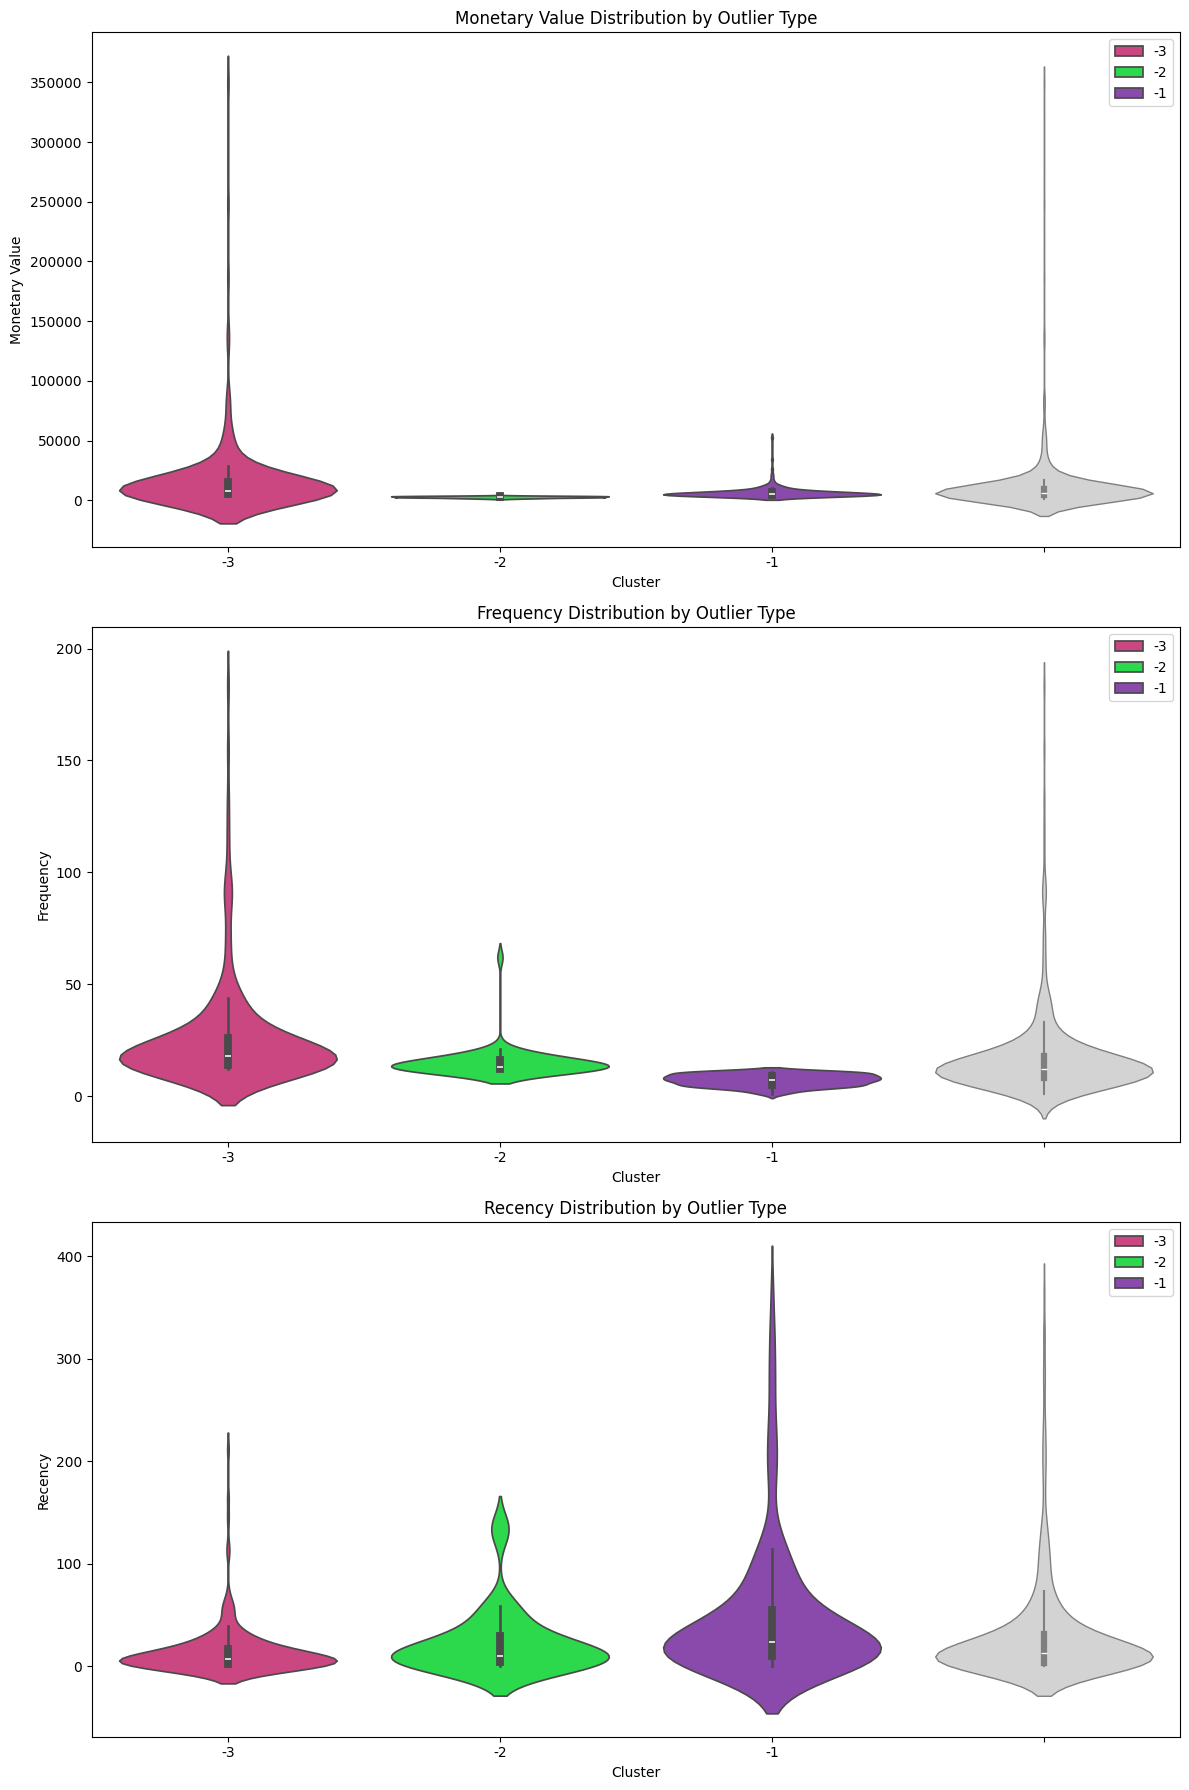

In [84]:
cluster_colors = {-1: "#8D39BD",
                  -2: "#10F43A",
                  -3: "#E1317E",
                  }


plt.figure(figsize = (12,18))

plt.subplot(3,1,1)
sns.violinplot(x = outliers_cluster_df['Cluster'], y = outliers_cluster_df['MonetaryValue'], palette = cluster_colors, hue = outliers_cluster_df['Cluster'])
sns.violinplot(y = outliers_cluster_df['MonetaryValue'], color = 'lightgray', linewidth= 1.0)
plt.title('Monetary Value Distribution by Outlier Type')
plt.ylabel('Monetary Value')

plt.subplot(3,1,2)
sns.violinplot(x = outliers_cluster_df['Cluster'], y = outliers_cluster_df['Frequency'], palette = cluster_colors, hue = outliers_cluster_df['Cluster'])
sns.violinplot(y = outliers_cluster_df['Frequency'], color = 'lightgray', linewidth= 1.0)
plt.title('Frequency Distribution by Outlier Type')
plt.ylabel('Frequency')

plt.subplot(3,1,3)
sns.violinplot(x = outliers_cluster_df['Cluster'], y = outliers_cluster_df['Recency'], palette = cluster_colors, hue = outliers_cluster_df['Cluster'])
sns.violinplot(y = outliers_cluster_df['Recency'], color = 'lightgray', linewidth= 1.0)
plt.title('Recency Distribution by Outlier Type')
plt.ylabel('Recency')

plt.tight_layout()
plt.show()

#### Cluster -1(Purple): ***Pamper***
##### Characterstics: High spenders but not necessarily frequent buyers. Their purchases are large but infrequent.
##### Strategy: Focus on maintaining their loyalty with personalized offers or luxury services that cater to their high spending capacity.

#### Cluster -2(Green): ***Upsell***
##### Characterstics: Frequent buyers who spend less per purchase. These customers are cosnsistently engaged but might benifit from upselling opportunities.
##### Strategy: Implement loyalty programs or bundle deals to encourage higher spending per visit.

#### Cluster -3(Pink): ***Delight***
##### Characterstics: The most valuable customers/outliers with extreme spending and frequent purchases. They are likely the top-tier customers who require special attention.
##### Strategy: Develop VIP programs or exclusive offers to maintain their loyalty and encourage continued engagement.

In [86]:
cluster_labels = {0: 'Retain',
                  1: 'Re-Engage',
                  2: 'Nurture',
                  3: 'Reward',
                  -1: 'Pamper',
                  -2: 'Upsell',
                  -3: 'Delight'
}

In [88]:
full_clustering = pd.concat([non_outliers_df, outliers_cluster_df])
full_clustering['ClusterLabel'] = full_clustering['Cluster'].map(cluster_labels)
full_clustering

,Customer ID,MonetaryValue,Frequency,LastPurchase,Recency,Cluster,ClusterLabel
0,12346.0,169.36,2,2010-06-28 13:53:00,164,1,Re-Engage
1,12347.0,1323.32,2,2010-12-07 14:57:00,2,0,Retain
2,12348.0,221.16,1,2010-09-27 14:59:00,73,2,Nurture
3,12349.0,2221.14,2,2010-10-28 08:23:00,42,0,Retain
4,12351.0,300.93,1,2010-11-29 15:23:00,10,2,Nurture
...,...,...,...,...,...,...,...
4235,18223.0,7516.31,12,2010-11-17 12:20:00,22,-3,Delight
4236,18225.0,7545.14,15,2010-12-09 15:46:00,0,-3,Delight
4237,18226.0,6650.83,15,2010-11-26 15:51:00,13,-3,Delight
4241,18231.0,4791.80,23,2010-10-29 14:17:00,41,-3,Delight


## Visualization of Clusters

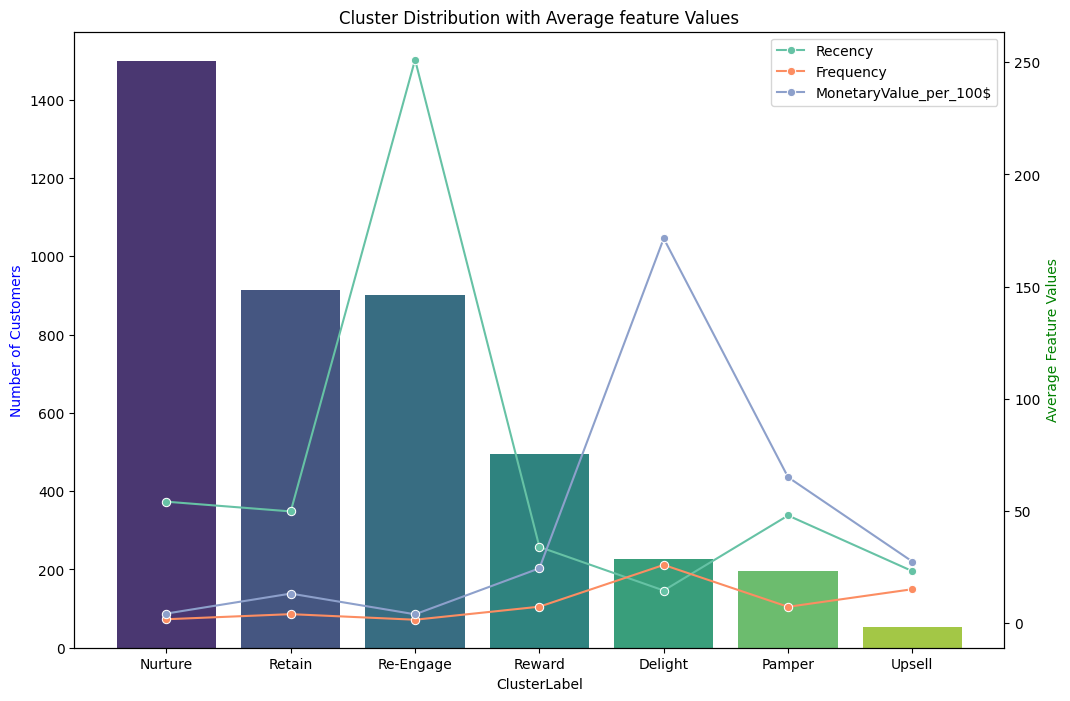

In [92]:
cluster_count = full_clustering['ClusterLabel'].value_counts()

full_clustering['MonetaryValue_per_100$'] = full_clustering['MonetaryValue'] / 100

feature_means = full_clustering.groupby('ClusterLabel')[['Recency', 'Frequency', 'MonetaryValue_per_100$']].mean()

fig, ax1 = plt.subplots(figsize=(12, 8))

sns.barplot(x=cluster_count.index, y=cluster_count.values, ax=ax1, palette='viridis', hue = cluster_count.index)
ax1.set_ylabel('Number of Customers' , color = 'b')
ax1.set_title('Cluster Distribution with Average feature Values')

ax2 = ax1.twinx()
sns.lineplot(data=feature_means, marker = 'o', dashes=False, ax=ax2, palette='Set2')
ax2.set_ylabel('Average Feature Values', color='g')

plt.show()